# 01 Data Understanding

This notebook was created to explore and understand the characteristics of our dataset.

## Data Overview

This project use "ข้อมูลบูรณาการผู้เสียชีวิตจากอุบัติเหตุทางถนน" from [https://data.go.th](https://data.go.th/dataset/rtddi).

The dataset is collected and maintained by the Department of Disease Control and compiles road traffic fatality records from multiple administrative sources (a “3-source integrated system”), including official death records and related reporting systems.

Each row in the dataset represents one fatal road accident event in Thailand, providing structured information about the incident such as time, location, and victim-related attributes.

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


## Schema Inspection

In this section we will explore deeper in structure of data.

### Test languages encoding method

In [ ]:
allFiles = glob.glob("../data/dataset_acc-sample/*.csv")
dataframes = pd.DataFrame()
encodings = ["utf-8", "cp874", "tis-620", "utf-8-sig", "latin1"]

for file in allFiles:
    for enc in encodings:
        try:
            df = pd.read_csv(file, encoding=enc)
            print(f"{file}: Loaded with {enc}")
            break
        except Exception as e:
            continue
              

../data/dataset_acc\_2554.csv: Loaded with cp874
../data/dataset_acc\_2555.csv: Loaded with cp874
../data/dataset_acc\_2556.csv: Loaded with cp874
../data/dataset_acc\_2557.csv: Loaded with cp874
../data/dataset_acc\_2558.csv: Loaded with cp874
../data/dataset_acc\_2559.csv: Loaded with cp874
../data/dataset_acc\_2560.csv: Loaded with cp874
../data/dataset_acc\_2561.csv: Loaded with cp874
../data/dataset_acc\_2562.csv: Loaded with cp874
../data/dataset_acc\_2563.csv: Loaded with cp874
../data/dataset_acc\_2564.csv: Loaded with cp874
../data/dataset_acc\_2565.csv: Loaded with cp874
../data/dataset_acc\_2566.csv: Loaded with cp874
../data/dataset_acc\_2567.csv: Loaded with utf-8
../data/dataset_acc\_2568.csv: Loaded with utf-8


**Note:** Before 2567 we will use cp874 to read data but after that we will use utf-8. This mean we can not ensure that in the future it will use the specific one encoding method.

### Append all dataset

In [3]:
dfs = []

for file in allFiles:
    for enc in encodings:
        try:
            df = pd.read_csv(file, encoding=enc)
            dfs.append(df)
            print(f'[{file}] appended.')
            break
        except Exception:
            continue

full_df = pd.concat(dfs, ignore_index=True)

[../data/dataset_acc\_2554.csv] appended.
[../data/dataset_acc\_2555.csv] appended.
[../data/dataset_acc\_2556.csv] appended.
[../data/dataset_acc\_2557.csv] appended.
[../data/dataset_acc\_2558.csv] appended.
[../data/dataset_acc\_2559.csv] appended.
[../data/dataset_acc\_2560.csv] appended.
[../data/dataset_acc\_2561.csv] appended.
[../data/dataset_acc\_2562.csv] appended.
[../data/dataset_acc\_2563.csv] appended.
[../data/dataset_acc\_2564.csv] appended.
[../data/dataset_acc\_2565.csv] appended.
[../data/dataset_acc\_2566.csv] appended.
[../data/dataset_acc\_2567.csv] appended.
[../data/dataset_acc\_2568.csv] appended.


### Dataset information

In [4]:
full_df.shape

(291977, 23)

**Note:** The dataset contains 291977 records and 23 attributes describing road accident fatalities

In [5]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 291977 entries, 0 to 291976
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Dead Conso Id              291977 non-null  int64  
 1   Dead Year_ปีที่เสียชีวิต   291977 non-null  int64  
 2   DEAD_YEAR                  291977 non-null  int64  
 3   Age                        261522 non-null  float64
 4   Sex                        291976 non-null  str    
 5   Nationality Id             150269 non-null  object 
 6   Tumbol                     34258 non-null   object 
 7   District                   106047 non-null  object 
 8   Province                   106229 non-null  object 
 9   Risk Helmet                4390 non-null    float64
 10  Risk Safety Belt           2066 non-null    float64
 11  Dead Date Final            275899 non-null  str    
 12  Date Rec                   106950 non-null  object 
 13  Time Rec                   106950 non-nu

**Note:** From the information above, we can categorize the columns into:

- **Location information**
  - `Tumbol`, `District`, `Province`
  - `Acc Sub Dist`, `Acc Dist`, `จ.ที่เสียชีวิต`
  - `Acc La`, `Acclong`
  - `acc_district_name`

- **Date and time information**
  - `Dead Year_ปีที่เสียชีวิต`
  - `DEAD_YEAR`
  - `Dead Date Final`
  - `Dead Date`
  - `Date Rec`
  - `Time Rec`

- **Demographic information**
  - `Age`
  - `Sex`
  - `Nationality Id`

- **Safety information**
  - `Risk Helmet`
  - `Risk Safety Belt`

- **Accident information**
  - `Vehicle Merge Final`
  - `Ncause`

- **identifier information**
  - `Dead Conso Id`

The result also show that name of some columns such as `Dead Date` with `Dead Date Final` and `Acc Dist` with `acc_district_name`has been change on some year.

In [6]:
full_df.describe()

,Dead Conso Id,Dead Year_ปีที่เสียชีวิต,DEAD_YEAR,Age,Risk Helmet,Risk Safety Belt,Acc La,Acclong
count,2.919770e+05,291977.000000,291977.000000,261522.000000,4390.000000,2066.000000,128003.000000,128002.000000
mean,9.251925e+06,2560.599349,2017.599349,40.713951,1.794989,2.264763,19.073891,96.450071
std,2.519030e+06,4.275136,4.275136,19.910001,0.513542,0.519906,19.572254,19.672803
min,1.000000e+00,2554.000000,2011.000000,-22.000000,1.000000,1.000000,-74.389096,-92.511648
25%,8.653605e+06,2557.000000,2014.000000,24.000000,1.000000,2.000000,13.647341,99.875525
50%,9.610037e+06,2560.000000,2017.000000,39.000000,2.000000,2.000000,14.816085,100.619009
75%,1.092532e+07,2564.000000,2021.000000,56.000000,2.000000,3.000000,16.799106,102.058617
max,1.168323e+07,2568.000000,2025.000000,154.000000,3.000000,3.000000,105.570887,105.599818


## Data Dictionary Review

|   Column Name |   Definition  |
|---------------|---------------|
|   DEAD_CONSO_ID   |   ลําดับผู้เสียชีวิตที่ระบบสร้างขึ้น  |
|   Dead Year_ปีที่เสียชีวิต  |   ปีที่เสียชีวิตของผู้ประสบเหตุ (พ.ศ.) |
|   DEAD_YEAR   |   ปีที่เสียชีวิตของผู้ประสบเหตุ (ค.ศ.) |
|   Age    |   อายุผู้เสียชีวิต |
|   Sex |   เพศผู้เสียชีวิต  |
|   Nationality Id  |   สัญชาติผู้เสียชีวิต(มรณบัตร) |
|   Tumbol  |   ตําบลที่อยู่ผู้เสียชีวิต (E-claim)    |
|   District    |   อําเภอที่อยู่ผู้เสียชีวิต (E-claim)   |
|   Province    |   จังหวัดที่อยู่ผู้เสียชีวิต (E-claim)   |
|   Risk Helmet |   การสวมหมวกของผู้เสียชีวิต   1,2,3 (มี ไม่มี ไม่ทราบ) |
|   RiskSafetyBelt  |   การคาดเข็มขัดนิรภัยของผู้เสียชีวิต   1,2,3 (มี ไม่มี ไม่ทราบ)|
|   Dead Date   |   วันที่เสียชีวิต   |
|   Date Rec    |   วันที่เกิดเหตุ   |
|   Time Rec    |   เวลาเกิดเหตุ  |
|   Acc Sub Dist    |   ตําบลเกิดเหตุ  |
|   acc_district_name   |   อําเภอเกิดเหตุ |
|   จ.ที่เสียชีวิต   |   จังหวัดเกิดเหตุ |
|   Acc La  |   ค่าพิกัด Latitude  |
|   Acclong |   ค่าพิกัด Longitude |
|   Ncause  |   รหัส ICD-10  |
|   Vehicle Merge Final |   พาหนะที่ประสบอุบัติเหตุ   |

## Missing Value Analysis

In [7]:
full_df.isna().any()

Dead Conso Id                False
Dead Year_ปีที่เสียชีวิต     False
DEAD_YEAR                    False
Age                           True
Sex                           True
Nationality Id                True
Tumbol                        True
District                      True
Province                      True
Risk Helmet                   True
Risk Safety Belt              True
Dead Date Final               True
Date Rec                      True
Time Rec                      True
Acc Sub Dist                  True
Acc Dist                      True
จ.ที่เสียชีวิต               False
Acc La                        True
Acclong                       True
Ncause                        True
Vehicle Merge Final          False
acc_district_name             True
Dead Date                     True
dtype: bool

## Overall percent

In [8]:
result = pd.DataFrame({
    'na_count': full_df.isna().sum(),
    'pct_na': full_df.isna().mean() * 100,
    'non_na_count': full_df.notna().sum()
})

result

,na_count,pct_na,non_na_count
Dead Conso Id,0,0.000000,291977
Dead Year_ปีที่เสียชีวิต,0,0.000000,291977
DEAD_YEAR,0,0.000000,291977
Age,30455,10.430616,261522
Sex,1,0.000342,291976
Nationality Id,141708,48.533960,150269
Tumbol,257719,88.266884,34258
District,185930,63.679673,106047
Province,185748,63.617340,106229
Risk Helmet,287587,98.496457,4390


**Note:** A portion of the N/A values observed in the table does not indicate missing information in the original data. Instead, these values were generated because certain source files use different column names for the same attribute, resulting in unmatched columns during the merge process.

In [9]:
# Missing rate by year
full_df.groupby('DEAD_YEAR')['Time Rec'].agg(
    total='size',
    missing=lambda x: x.isna().sum(),
    missing_pct=lambda x: round(x.isna().mean() * 100, 2)
)

,total,missing,missing_pct
DEAD_YEAR,,,
2011,21996,11606,52.76
2012,21603,11179,51.75
2013,21221,11331,53.40
2014,20790,11101,53.40
2015,19960,11318,56.70
2016,21745,11902,54.73
2017,21607,11434,52.92
2018,19931,10029,50.32
2019,19904,9535,47.90


In [10]:
# Missing rate by year
full_df.groupby('DEAD_YEAR')['Date Rec'].agg(
    total='size',
    missing=lambda x: x.isna().sum(),
    missing_pct=lambda x: round(x.isna().mean() * 100, 2)
)

,total,missing,missing_pct
DEAD_YEAR,,,
2011,21996,11606,52.76
2012,21603,11179,51.75
2013,21221,11331,53.40
2014,20790,11101,53.40
2015,19960,11318,56.70
2016,21745,11902,54.73
2017,21607,11434,52.92
2018,19931,10029,50.32
2019,19904,9535,47.90


In [11]:
full_df[(full_df["Time Rec"].notna()) & (full_df["Date Rec"].isna())].head()

,Dead Conso Id,Dead Year_ปีที่เสียชีวิต,DEAD_YEAR,Age,Sex,Nationality Id,Tumbol,District,Province,Risk Helmet,Risk Safety Belt,Dead Date Final,Date Rec,Time Rec,Acc Sub Dist,Acc Dist,จ.ที่เสียชีวิต,Acc La,Acclong,Ncause,Vehicle Merge Final,acc_district_name,Dead Date


In [12]:
full_df[(full_df["Time Rec"].isna()) & (full_df["Date Rec"].notna())].head()

,Dead Conso Id,Dead Year_ปีที่เสียชีวิต,DEAD_YEAR,Age,Sex,Nationality Id,Tumbol,District,Province,Risk Helmet,Risk Safety Belt,Dead Date Final,Date Rec,Time Rec,Acc Sub Dist,Acc Dist,จ.ที่เสียชีวิต,Acc La,Acclong,Ncause,Vehicle Merge Final,acc_district_name,Dead Date


**Note:** The Time Rec and Date Rec attribute has substantial missing values, with all records from 2022 onward missing. This indicates systematic missingness, so time-based analyses were limited to records with available timestamps. Time Rec and Date Rec are corelate if one is N/A other will be N/A.

In [13]:
full_df[full_df["Acc La"].isna() != full_df["Acclong"].isna()]

,Dead Conso Id,Dead Year_ปีที่เสียชีวิต,DEAD_YEAR,Age,Sex,Nationality Id,Tumbol,District,Province,Risk Helmet,Risk Safety Belt,Dead Date Final,Date Rec,Time Rec,Acc Sub Dist,Acc Dist,จ.ที่เสียชีวิต,Acc La,Acclong,Ncause,Vehicle Merge Final,acc_district_name,Dead Date
189621,10913427,2563,2020,41.0,ชาย,99.0,NaN,ปะทิว,ชุมพร,NaN,NaN,17/1/2020,17/1/2563,1/1/1900 9:00,วังไผ่,เมืองชุมพร,ชุมพร,10.524191,NaN,V892,รถจักรยานยนต์,NaN,NaN
227161,11489614,2565,2022,30.0,ชาย,Bruneian,NaN,บางขุนเทียน,กรุงเทพมหานคร,NaN,NaN,13/3/2022,NaN,NaN,บางบอนใต้,บางบอน,กรุงเทพมหานคร,NaN,100.387515,NaN,รถยนต์,NaN,NaN
228485,11489757,2565,2022,25.0,หญิง,Thai,NaN,ท่าแซะ,ชุมพร,NaN,NaN,9/4/2022,NaN,NaN,รับร่อ,ท่าแซะ,ชุมพร,10.772105,NaN,NaN,รถจักรยานยนต์,NaN,NaN


In [14]:
full_df[(full_df["Acc La"].isna()) & (full_df["Acclong"].isna())].head()

,Dead Conso Id,Dead Year_ปีที่เสียชีวิต,DEAD_YEAR,Age,Sex,Nationality Id,Tumbol,District,Province,Risk Helmet,Risk Safety Belt,Dead Date Final,Date Rec,Time Rec,Acc Sub Dist,Acc Dist,จ.ที่เสียชีวิต,Acc La,Acclong,Ncause,Vehicle Merge Final,acc_district_name,Dead Date
0,8600819,2554,2011,38.0,ชาย,99.0,NaN,NaN,NaN,NaN,NaN,1/1/2011,NaN,NaN,NaN,NaN,กำแพงเพชร,NaN,NaN,V499,รถยนต์,NaN,NaN
1,8600823,2554,2011,41.0,ชาย,99.0,NaN,NaN,NaN,NaN,NaN,1/1/2011,NaN,NaN,NaN,NaN,ลพบุรี,NaN,NaN,V499,รถยนต์,NaN,NaN
2,8600822,2554,2011,54.0,ชาย,99.0,NaN,NaN,NaN,NaN,NaN,1/1/2011,NaN,NaN,NaN,NaN,อุดรธานี,NaN,NaN,V899,ไม่ระบุพาหนะ,NaN,NaN
3,8610778,2554,2011,NaN,ไม่ระบุ,NaN,NaN,NaN,NaN,NaN,NaN,1/1/2011,NaN,NaN,NaN,NaN,นครสวรรค์,NaN,NaN,NaN,ไม่ระบุพาหนะ,NaN,NaN
4,8608938,2554,2011,NaN,ไม่ระบุ,NaN,NaN,NaN,NaN,NaN,NaN,1/1/2011,NaN,NaN,NaN,NaN,ชลบุรี,NaN,NaN,NaN,ไม่ระบุพาหนะ,NaN,NaN


In [15]:
full_df[(full_df["Acc La"].isna()) & (full_df["Acclong"].isna()) & (full_df["Acc Dist"].notna())].head()

,Dead Conso Id,Dead Year_ปีที่เสียชีวิต,DEAD_YEAR,Age,Sex,Nationality Id,Tumbol,District,Province,Risk Helmet,Risk Safety Belt,Dead Date Final,Date Rec,Time Rec,Acc Sub Dist,Acc Dist,จ.ที่เสียชีวิต,Acc La,Acclong,Ncause,Vehicle Merge Final,acc_district_name,Dead Date
43,8596610,2554,2011,20.0,ชาย,99.0,ป่าตึง,แม่จัน,ชร,NaN,NaN,1/1/2011,1/1/2554,1/1/1900 16:30,ป่าตึง,แม่จัน,เชียงราย,NaN,NaN,V899,ไม่ระบุพาหนะ,NaN,NaN
47,8606453,2554,2011,NaN,ชาย,NaN,แม่กรณ์,เมืองเชียงราย,ชร,NaN,NaN,1/1/2011,1/1/2554,1/1/1900 1:30,ศาลาธรรมศพน์,ทวีวัฒนา,กรุงเทพมหานคร,NaN,NaN,NaN,ไม่ระบุพาหนะ,NaN,NaN
48,8605700,2554,2011,NaN,ชาย,NaN,ห้างสูง,หนองใหญ่,ชบ,NaN,NaN,1/1/2011,1/1/2554,1/1/1900 19:30,หมอนนาง,พนัสนิคม,ชลบุรี,NaN,NaN,NaN,ไม่ระบุพาหนะ,NaN,NaN
49,8605701,2554,2011,NaN,ชาย,NaN,หนองเรือ,ชุมพลบุรี,สร,NaN,NaN,1/1/2011,1/1/2554,1/1/1900 23:30,หัวถนน,พนัสนิคม,ชลบุรี,NaN,NaN,NaN,ไม่ระบุพาหนะ,NaN,NaN
53,8606561,2554,2011,NaN,ชาย,NaN,สัตหีบ,สัตหีบ,ชบ,NaN,NaN,1/1/2011,1/1/2554,1/1/1900 18:30,ทรงธรรม,เมืองกำแพงเพชร,กำแพงเพชร,NaN,NaN,NaN,ไม่ระบุพาหนะ,NaN,NaN


In [16]:
full_df[(full_df["Acc La"].isna()) | (full_df["Acclong"].isna())]["DEAD_YEAR"].value_counts()

DEAD_YEAR
2011    14702
2024    13421
2025    13368
2016    11904
2017    11451
2013    11332
2015    11319
2012    11263
2014    11101
2018    10208
2019     9786
2023     9034
2020     9000
2021     8444
2022     7643
Name: count, dtype: int64

**Note:** Half of latitude and longitude contain missing values. Most records with missing coordinates are concentrated in 2011, suggesting lower geospatial data completeness during the early years of data collection. However, missing coordinate values are still observed in recent years.

In [45]:
full_df.groupby('DEAD_YEAR')['Risk Helmet'].agg(
    total='size',
    missing=lambda x: x.isna().sum(),
    missing_pct=lambda x: round(x.isna().mean() * 100, 2)
)

,total,missing,missing_pct
DEAD_YEAR,,,
2011,21996,21983,99.94
2012,21603,20822,96.38
2013,21221,19500,91.89
2014,20790,18915,90.98
2015,19960,19960,100.00
2016,21745,21745,100.00
2017,21607,21607,100.00
2018,19931,19931,100.00
2019,19904,19904,100.00


In [ ]:
full_df.groupby('DEAD_YEAR')['Risk Safety Belt'].agg(
    total='size',
    missing=lambda x: x.isna().sum(),
    missing_pct=lambda x: round(x.isna().mean() * 100, 2)
)

,total,missing,missing_pct
DEAD_YEAR,,,
2011,21996,21988,99.96
2012,21603,21320,98.69
2013,21221,20482,96.52
2014,20790,19754,95.02
2015,19960,19960,100.00
2016,21745,21745,100.00
2017,21607,21607,100.00
2018,19931,19931,100.00
2019,19904,19904,100.00


**Note:** Both Risk columns contain empty value since 2015.

## Uniqueness & Cardinality

### Overall

In [18]:
full_df.duplicated().sum()

np.int64(0)

In [19]:
full_df.nunique()

Dead Conso Id                291977
Dead Year_ปีที่เสียชีวิต         15
DEAD_YEAR                        15
Age                             119
Sex                               3
Nationality Id                  107
Tumbol                         5485
District                        990
Province                        155
Risk Helmet                       3
Risk Safety Belt                  3
Dead Date Final                5114
Date Rec                       4018
Time Rec                       1440
Acc Sub Dist                   5984
Acc Dist                        992
จ.ที่เสียชีวิต                   78
Acc La                       117731
Acclong                      116214
Ncause                          376
Vehicle Merge Final              10
acc_district_name               972
Dead Date                       365
dtype: int64

**Note:** A duplicate check was performed across all columns, and no duplicate records were detected. Therefore, each row can be treated as a unique observation for subsequent analysis.

In [20]:
Dead_date_compare = full_df.loc[
    (full_df["DEAD_YEAR"] < 2022) &
    (full_df["Date Rec"].notna()),
    ["Dead Date Final", "Date Rec"]
]

Dead_date_compare['Dead Date Final'] = Dead_date_compare['Dead Date Final'].str.split('/').str[:2].str.join('/')
Dead_date_compare['Date Rec'] = Dead_date_compare['Date Rec'].str.split('/').str[:2].str[::-1].str.join('/')

Dead_date_compare.head()

,Dead Date Final,Date Rec
5,1/1,1/1
6,1/1,1/1
7,1/1,1/1
36,1/1,1/1
37,1/1,1/1


In [21]:
Dead_date_compare_not_equal = Dead_date_compare[Dead_date_compare['Dead Date Final'] != Dead_date_compare['Date Rec']]
Dead_date_compare_not_equal.head()

,Dead Date Final,Date Rec
184,2/1,3/1
190,2/1,1/1
191,2/1,1/1
194,2/1,1/1
196,2/1,1/1


In [22]:
Dead_date_compare_not_equal.shape[0]

45619

## Data Consistency Checks

### Nationality Id

In [23]:
full_df["Nationality Id"].unique()


array([99.0, nan, 71.0, 208.0, 25.0, 56.0, 82.0, 9.0, 45.0, 198.0, 44.0,
       48.0, 199.0, 36.0, 57.0, 72.0, 38.0, 96.0, 30.0, 98.0, 258.0, 49.0,
       126.0, 259.0, 46.0, 'Thai', 'Lao Laotian', 'Cambodian', 'Burmese',
       'German', 'Belarusian', 'Norwegian', 'Danish Dane', 'Bahamian',
       'Beninese', 'Israeli', 'Malian', 'Ecuadorian', 'American',
       'Japanese', 'Dutch Dutchman', 'Afghan', 'Bahraini', 'Bruneian',
       'Romanian', 'Macedonian', 'Yemeni', 'Colombian', 'Icelander',
       'Malawian', 'Australian', 'British Briton', 'Chinese', 'Swazi',
       'Malaysian', 'Comoran', 'Austrian', 'Ukrainian', 'Italian',
       'Iranian', 'Russian', 'French', 'Vietnamese', 'Cuban', 'Belgian',
       'Swedish Swede', 'Bosnian Herzegovinian', 'Polish Pole',
       'Burundian', 'Lithuanian', 'British/Briton', 'Lao, Laotian',
       'Filipino', 'Bermudan', 'Dutch/Dutchman', 'Kazakhstani',
       'Irish/Irishman', 'Tanzanian', 'Polish/Pole', 'Swedish/Swede',
       'Singaporean', 'S

### Province

In [24]:
full_df["Province"].unique()


array([nan, 'ลบ', 'มห', 'นม', 'นพ', 'ชม', 'อย', 'บร', 'ภก', 'ชร', 'ปน',
       'สพ', 'กท', 'ชบ', 'สร', 'อด', 'มค', 'สส', 'ตร', 'พช', 'สฎ', 'พล',
       'สข', 'สต', 'ปข', 'สน', 'นว', 'ปจ', 'ขก', 'ลพ', 'นฐ', 'นย', 'รบ',
       'จบ', 'สห', 'พย', 'ยส', 'ปท', 'สก', 'กจ', 'รย', 'ตง', 'สบ', 'อบ',
       'อน', 'ศก', 'ชน', 'ลป', 'ฉช', 'นค', 'นภ', 'กบ', 'นศ', 'รอ', 'อจ',
       'อต', 'ตก', 'กส', 'นบ', 'กพ', 'พจ', 'สท', 'สป', 'พง', 'นน', 'พท',
       'สค', 'ลย', 'ชพ', 'ชย', 'ยล', 'พร', 'รน', 'มส', 'อท', 'พบ', 'นธ',
       'ec', 'บก', 'เชียงใหม่', 'ร้อยเอ็ด', 'ลำปาง', 'อุดรธานี',
       'สมุทรสาคร', 'นครพนม', 'นครศรีธรรมราช', 'ภูเก็ต', 'เพชรบูรณ์',
       'กาญจนบุรี', 'บึงกาฬ', 'สุพรรณบุรี', 'ลพบุรี', 'นครสวรรค์',
       'ราชบุรี', 'นครนายก', 'นครราชสีมา', 'ศรีสะเกษ', 'สระแก้ว',
       'สกลนคร', 'กำแพงเพชร', 'อุตรดิตถ์', 'กรุงเทพมหานคร', 'สระบุรี',
       'สมุทรปราการ', 'น่าน', 'ระนอง', 'พระนครศรีอยุธยา', 'อ่างทอง',
       'พิษณุโลก', 'สงขลา', 'มุกดาหาร', 'ยโสธร', 'ลำพูน', 'นครปฐม',
       'สิงห์บ

**Note:** From the result province column contain mixture of format and also contain some unknown value.

In [25]:
full_df["จ.ที่เสียชีวิต"].unique()

<StringArray>
[      'กำแพงเพชร',          'ลพบุรี',        'อุดรธานี',       'นครสวรรค์',
          'ชลบุรี',   'กรุงเทพมหานคร',        'มุกดาหาร',      'ปราจีนบุรี',
        'ศรีสะเกษ',       'กาญจนบุรี',         'สระแก้ว',           'ระยอง',
        'สุรินทร์',          'สกลนคร',     'สมุทรสงคราม',         'นนทบุรี',
        'ปทุมธานี',     'อุบลราชธานี',         'ขอนแก่น',        'ร้อยเอ็ด',
        'เชียงราย',          'นครปฐม',         'ราชบุรี',    'สุราษฎร์ธานี',
     'สมุทรปราการ',          'ชัยนาท',      'นครราชสีมา',          'นครพนม',
       'เชียงใหม่',       'บุรีรัมย์',          'ภูเก็ต',         'ปัตตานี',
       'กาฬสินธุ์',            'ตราด',       'เพชรบูรณ์',        'พิษณุโลก',
           'สงขลา',            'สตูล', 'ประจวบคีรีขันธ์',        'จันทบุรี',
      'ฉะเชิงเทรา',       'อุตรดิตถ์',       'อุทัยธานี',           'ลำพูน',
         'นครนายก',         'สุโขทัย',         'ชัยภูมิ',       'มหาสารคาม',
           'พะเยา',           'ชุมพร', 'พระนครศรีอยุธยา',     

**Note:** In "จ.ที่เสียชีวิต" handle N/A with "ไม่ทราบจังหวัด"

In [26]:
living_province = full_df["Province"]
dead_province = full_df["จ.ที่เสียชีวิต"]

all_province = pd.concat([living_province, dead_province])

In [27]:
all_province.unique()

array([nan, 'ลบ', 'มห', 'นม', 'นพ', 'ชม', 'อย', 'บร', 'ภก', 'ชร', 'ปน',
       'สพ', 'กท', 'ชบ', 'สร', 'อด', 'มค', 'สส', 'ตร', 'พช', 'สฎ', 'พล',
       'สข', 'สต', 'ปข', 'สน', 'นว', 'ปจ', 'ขก', 'ลพ', 'นฐ', 'นย', 'รบ',
       'จบ', 'สห', 'พย', 'ยส', 'ปท', 'สก', 'กจ', 'รย', 'ตง', 'สบ', 'อบ',
       'อน', 'ศก', 'ชน', 'ลป', 'ฉช', 'นค', 'นภ', 'กบ', 'นศ', 'รอ', 'อจ',
       'อต', 'ตก', 'กส', 'นบ', 'กพ', 'พจ', 'สท', 'สป', 'พง', 'นน', 'พท',
       'สค', 'ลย', 'ชพ', 'ชย', 'ยล', 'พร', 'รน', 'มส', 'อท', 'พบ', 'นธ',
       'ec', 'บก', 'เชียงใหม่', 'ร้อยเอ็ด', 'ลำปาง', 'อุดรธานี',
       'สมุทรสาคร', 'นครพนม', 'นครศรีธรรมราช', 'ภูเก็ต', 'เพชรบูรณ์',
       'กาญจนบุรี', 'บึงกาฬ', 'สุพรรณบุรี', 'ลพบุรี', 'นครสวรรค์',
       'ราชบุรี', 'นครนายก', 'นครราชสีมา', 'ศรีสะเกษ', 'สระแก้ว',
       'สกลนคร', 'กำแพงเพชร', 'อุตรดิตถ์', 'กรุงเทพมหานคร', 'สระบุรี',
       'สมุทรปราการ', 'น่าน', 'ระนอง', 'พระนครศรีอยุธยา', 'อ่างทอง',
       'พิษณุโลก', 'สงขลา', 'มุกดาหาร', 'ยโสธร', 'ลำพูน', 'นครปฐม',
       'สิงห์บ

In [28]:
all_province.nunique()

156

**Note:** 2 province columns use exactly the same in case province in fullname.

### District

In [29]:
full_df["District"].value_counts()

District
เมืองอุดรธานี             679
เมือง                     628
เมืองนครราชสีมา           599
เมืองขอนแก่น              589
เมืองสมุทรปราการ          577
เมืองนครปฐม               535
เมืองลพบุรี               527
เมืองเชียงราย             520
เมืองเพชรบูรณ์            502
เมืองลำปาง                494
เมืองพิษณุโลก             478
เมืองนครสวรรค์            470
บางละมุง                  456
เมืองกำแพงเพชร            451
ศรีราชา                   443
เมืองสุรินทร์             429
เมืองระยอง                428
เมืองชลบุรี               414
เมืองราชบุรี              406
เมืองสกลนคร               405
เมืองสมุทรสาคร            393
เมืองบุรีรัมย์            381
เมืองเชียงใหม่            369
เมืองสุพรรณบุรี           361
เมืองลำพูน                360
ปากช่อง                   360
หาดใหญ่                   358
คลองหลวง                  358
บ้านโป่ง                  341
เมืองตรัง                 332
สามพราน                   330
เมืองภูเก็ต               325
กบินทร์บุรี               323
ห

In [30]:
acc_dist= pd.concat([full_df["Acc Dist"], full_df["acc_district_name"]])

In [31]:
acc_dist.value_counts()

ศรีราชา                     1628
เมืองนครราชสีมา             1615
เมืองระยอง                  1477
เมืองชลบุรี                 1286
บางละมุง                    1279
เมืองขอนแก่น                1276
เมืองเชียงราย               1274
เมืองอุดรธานี               1152
เมืองเชียงใหม่              1126
เมืองสมุทรสาคร              1075
เมืองสมุทรปราการ            1073
เมืองนครปฐม                 1017
เมืองพิษณุโลก                993
เมืองอุบลราชธานี             940
เมืองลำปาง                   917
เมืองนครสวรรค์               900
บางพลี                       899
เมือง                        858
เมืองสุรินทร์                839
หาดใหญ่                      825
เมืองลพบุรี                  803
เมืองลำพูน                   787
เมืองเพชรบูรณ์               765
เมืองกำแพงเพชร               763
คลองหลวง                     753
เมืองบุรีรัมย์               709
เมืองภูเก็ต                  701
ปากช่อง                      678
เมืองสกลนคร                  668
เมืองร้อยเอ็ด                662
เมืองสุพรร

**Note:** in acc_dist contain mixture of format.

### Sub district

In [32]:
full_df["Tumbol"].unique()

array([nan, 'เขาพระงาม', 'บ้านเป้า', ..., 'เหล่าไฮงาม', 'ถนนโพธิ์',
       'ท้ายเกาะ'], shape=(5486,), dtype=object)

In [33]:
full_df["Acc Sub Dist"].unique()

<StringArray>
[          nan,   'เขาพระงาม',     'ในเมือง',        'นาแก', 'สันทรายน้อย',
 'บ้านมะเกลือ',     'โคกกลาง',    'เชิงทะเล',      'ป่าตึง',        'ตุยง',
 ...
       'พญาไท',   'จะบังติกอ',  'บ้านราษฏร์',    'เมืองทอง',       'คงบัง',
      'มหาสอน',   'แหลมโพธิ์',     'พ่อมิ่ง',     'อ่อนนุช',    'บางเพลิง']
Length: 5985, dtype: str

### CID-10

In [34]:
full_df["Ncause"].value_counts()

Ncause
V892    111703
V299     27222
Y349     20324
V499      8567
V234      7849
V284      5529
V289      3779
V239      3631
X599      3186
V899      2725
V091      2563
V031      2539
V224      2414
V274      2362
V244      2084
V294      1508
V229      1201
V279      1135
V489      1132
V021      1114
V249      1090
V235      1013
V479       898
V099       732
V429       660
V475       592
V849       560
V285       490
V439       434
V041       420
V204       382
V485       373
V586       310
V039       306
V486       299
V435       298
V599       286
V589       285
V051       256
V575       252
V134       249
V445       248
V496       247
V245       246
V225       242
V449       237
V436       234
V476       233
V092       196
V296       195
V585       194
V579       175
V199       175
V536       171
V446       169
V689       169
V535       166
V576       162
V295       160
V546       153
V545       153
V029       146
V124       143
V699       131
V549       128
V275       122
V53

### Vehicle

In [35]:
full_df["Vehicle Merge Final"].value_counts()

Vehicle Merge Final
ไม่ระบุพาหนะ              134775
รถจักรยานยนต์             119794
รถยนต์                     20416
คนเดินเท้า                  8568
รถบรรทุกขนาดเล็ก/รถตู้      4742
รถจักรยาน                   1597
รถบรรทุกหนัก                1092
สามล้อ                       477
รถโดยสาร                     342
รถเพื่อการเกษตร              174
Name: count, dtype: int64

### Sex

In [36]:
full_df["Sex"].unique()

<StringArray>
['ชาย', 'ไม่ระบุ', 'หญิง', nan]
Length: 4, dtype: str

## Distribution Analysis

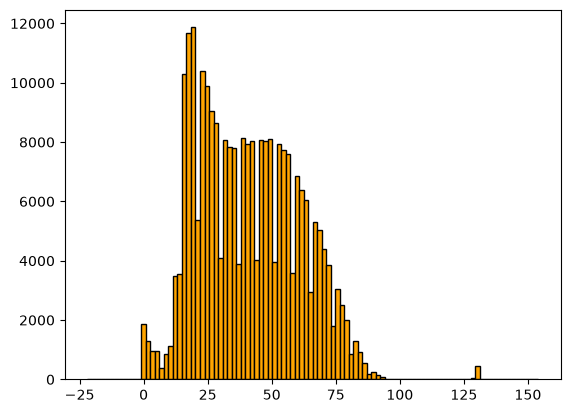

In [37]:
plt.hist(full_df["Age"],bins=100,color='orange', edgecolor='black')
plt.show()

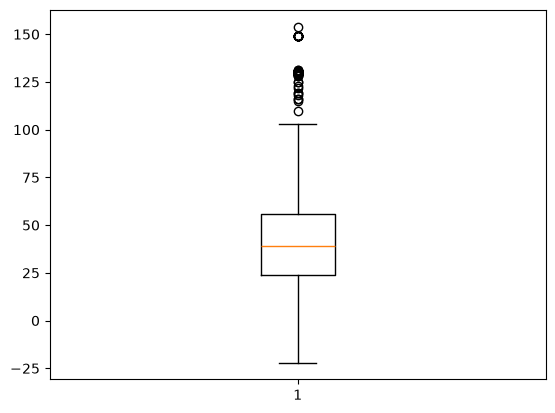

In [38]:
plt.boxplot(full_df["Age"].dropna())
plt.show()

**Note:** Age is concentrated between 20–60 years old with a median of approximately 39 years. Several observations above 100 years old are identified as boxplot outliers, although these values may still be valid. A small number of records exceed 120 years old and should be reviewed as potential data quality issues. The distribution also exhibits age heaping at rounded ages (e.g., 20, 25, 30, 35, 40), suggesting possible rounding during data collection.

## Initial Data Quality Assessment

|   Issue   |   Type    | Severity |   Action  |
|-----------|-----------|-----------|-----------|
|   98–99% missing values in  `Risk Helmet` and `Risk Safety BeltRisk`  |   Completeness    |   High | Consider to drop the columns or consolidate this 2 columns. |
|   `Date_rec` and `time_rec` contain 100% of missing value since 2022  |   Completeness    |  High    |   Retain in fact table for historical completeness; values after 2022 remain NULL due to upstream ingestion issue.   |
| Inconsistent date formats |   Consistency | High  |   Standardize date formats. |
|   `Date Rec` Accident date occurs after death date   |    Accuracy   |   High    |   Records in which the accident date occurs after the death date violate chronological consistency. Because the death date is considered more reliable, invalid accident dates are replaced with NULL during the ETL process.   |
|   Inconsistent / non-standard column naming conventions  |   Consistency |   Medium  |   Standardize column name |
|   Schema drift across years  |   Consistency   |   High    |   Map and consolidate columns into a single column    |
|   `Time Rec` contains date values instead of time-only values |   Consistency    |   High |   Standardize Time Rec to contain only time values during ETL |
|   `Nationality Id` contains inconsistent formats (ISO 3166 codes and full nationality names), including unmapped value  |   Consistency / Validity |   High    | Standardize to ISO 3166 where possible and assign unmapped values to Unknown   |
|   Missing value on `Sex`  |   Completeness    |   Low | Map to unknown    |
|   Missing values in `Acc La` and `Acclong` (~56%) |   Completeness    |   Medium  |   Retain the attributes because they provide valuable geospatial information. Missing values are preserved as NULL.   |
|   Province column contains inconsistent representations    |   Consistency |   High    |   Map all values to a standardized province reference    |
|   District column contains unexpected prefixes in values, leading to inconsistent representation of the same district   |   Consistency |   High    | Clean and standardize values by removing prefixes and mapping to reference  |
| Age contains invalid values outside valid range (age < 0 or > 110)   | Validity  |   High    | Validate age range (0–120). Set invalid values to NULL or flag for exclusion   |